In [14]:
# import tensorflow
import matplotlib.pyplot as plt 
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense ,Flatten

In [12]:
(X_train, y_train),(X_test, y_test) = keras.datasets.mnist.load_data()
X_train.shape

(60000, 28, 28)

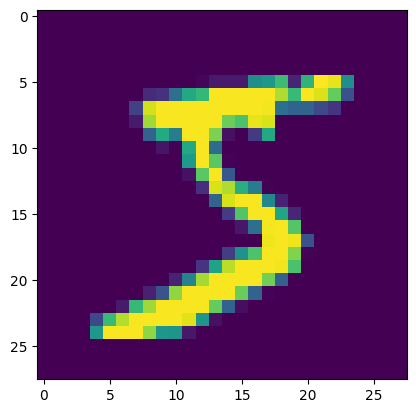

In [17]:
y_train # we have the image no. in our y label 
plt.imshow(X_train[0])

In [ ]:
# hence we have our data in {0-255} so to convert it in {0-1}
X_train = X_train/255
X_test = X_test/255

In [39]:
model = Sequential()
#hence we have the data in 2d [28x28] so we need to conert it into 1d so we use faltten meathod it convert the data in 1d
model.add(Flatten(input_shape=(28,28,1))) # we need to tell the shape of input in flatten
model.add(Dense(128, activation='relu')) # we need not to tell the shpae bcoz the flatten o/p is input for it 
model.add(Dense(10, activation='softmax')) # when we have more the 1 value in o/p in calssifiaction then we mostely use softmax 

c:\Users\shubham yadav\Desktop\jupyter\venv\Lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [40]:
print(model.summary())

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_2 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 101,770 (397.54 KB)

 Trainable params: 101,770 (397.54 KB)

 Non-trainable params: 0 (0.00 B)

None


In [41]:
# in this loss fun. we not need to do the one hot coding
model.compile(loss='sparse_categorical_crossentropy',optimizer='adam', metrics=['accuracy'])

In [45]:
history = model.fit(X_train, y_train, epochs=10, validation_split=.20)

Epoch 1/10
   1/1500 ━━━━━━━━━━━━━━━━━━━━ 46s 31ms/step - accuracy: 0.9375 - loss: 0.1761

1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9576 - loss: 0.1840 - val_accuracy: 0.9544 - val_loss: 0.2444
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9596 - loss: 0.1696 - val_accuracy: 0.9484 - val_loss: 0.2628
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9606 - loss: 0.1673 - val_accuracy: 0.9492 - val_loss: 0.2982
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9616 - loss: 0.1684 - val_accuracy: 0.9413 - val_loss: 0.3456
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9640 - loss: 0.1543 - val_accuracy: 0.9495 - val_loss: 0.3135
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9650 - loss: 0.1494 - val_accuracy: 0.9486 - val_loss: 0.3250
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9661 - loss: 0.1480 - val_accuracy: 0.9488 - val_loss: 0.2962
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9674 - loss: 0.1440 - val_accurac

In [43]:
y_prob = model.predict(X_test)
# hence y_prob have the prob of that perticuler image so we need to find that idx which have higest prob
y_pred = y_prob.argmax(axis=1)

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 817us/step


In [44]:
from sklearn.metrics import accuracy_score
accuracy_score(y_test, y_pred)

0.9461

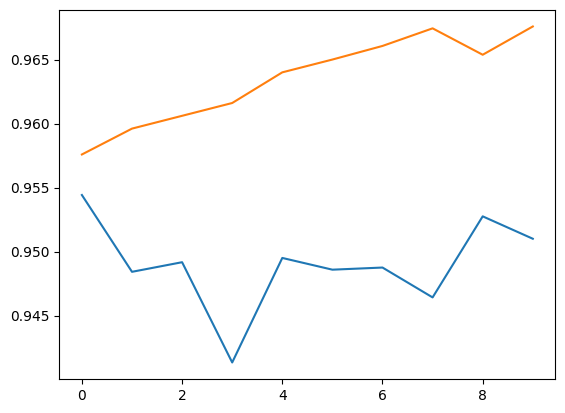

In [ ]:
plt.plot(history.history['val_accuracy'])
plt.plot(history.history['accuracy'])

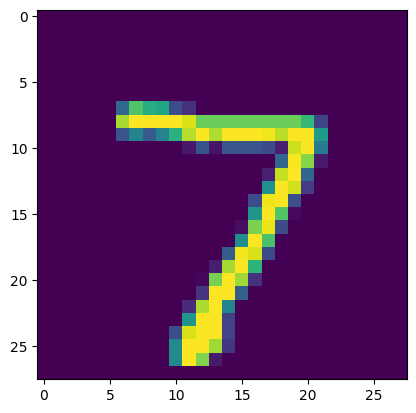

In [ ]:
plt.imshow(X_test[0]) # show what we have in our test data 

In [ ]:
model.predict(X_test[0].reshape(1,28,28)).argmax(axis=1) 
# heance our model is also pridicting 7

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step


array([7])